<a href="https://colab.research.google.com/github/Mikomijie/learning-python/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving grocery_chain_data.csv to grocery_chain_data.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
grocery_data= pd.read_csv('grocery_chain_data.csv')

In [7]:
grocery_data.head()

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,8/26/2023,Produce,Pasta,2,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2/13/2024,Dairy,Cheese,1,1.85,1.85,3.41,-1.56,111
2,4657,ValuePlus Market,11/23/2023,Bakery,Onions,4,7.38,29.52,4.04,25.48,301
3,2679,SuperSave Central,1/13/2025,Snacks & Candy,Cereal,3,5.50,16.50,1.37,15.13,490
4,9935,GreenGrocer Plaza,10/13/2023,Canned Goods,Orange Juice,5,8.66,43.30,1.50,41.80,22


In [8]:
grocery_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1980 entries, 0 to 1979
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       1980 non-null   int64  
 1   store_name        1955 non-null   object 
 2   transaction_date  1980 non-null   object 
 3   aisle             1980 non-null   object 
 4   product_name      1980 non-null   object 
 5   quantity          1980 non-null   int64  
 6   unit_price        1980 non-null   float64
 7   total_amount      1980 non-null   float64
 8   discount_amount   1980 non-null   float64
 9   final_amount      1980 non-null   float64
 10  loyalty_points    1980 non-null   int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 170.3+ KB


In [9]:
grocery_data.shape

(1980, 11)

In [10]:
grocery_data.head(3)

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,8/26/2023,Produce,Pasta,2,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2/13/2024,Dairy,Cheese,1,1.85,1.85,3.41,-1.56,111
2,4657,ValuePlus Market,11/23/2023,Bakery,Onions,4,7.38,29.52,4.04,25.48,301


In [11]:
print("The Most Expensive item cost: ",grocery_data['unit_price'].max())
print("The Least Expensive Item cost: ", grocery_data['unit_price'].min())
print("The Average Price is:",  round(grocery_data['unit_price'].mean(),2))

The Most Expensive item cost:  29.98
The Least Expensive Item cost:  0.99
The Average Price is: 15.49


In [12]:
grocery_data[grocery_data['unit_price'] == grocery_data['unit_price'].max()]

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
230,7745,GreenGrocer Plaza,4/21/2025,Dairy,Rice,4,29.98,119.92,2.64,117.28,368
425,4986,City Fresh Store,3/31/2024,Personal Care,Orange Juice,5,29.98,149.90,1.99,147.91,498


In [13]:
grocery_data[grocery_data['unit_price'] == grocery_data['unit_price'].min()]

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
517,2713,Corner Grocery,6/3/2025,Produce,Onions,5,0.99,4.95,3.25,1.7,46


In [14]:
grocery_data['store_name'].value_counts()

,count
store_name,
City Fresh Store,235
SuperSave Central,232
ValuePlus Market,221
GreenGrocer Plaza,220
Corner Grocery,218
FamilyFood Express,215
MegaMart Westside,214
QuickStop Market,208
FreshMart Downtown,192


In [15]:
grocery_data.head(2)

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,8/26/2023,Produce,Pasta,2,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2/13/2024,Dairy,Cheese,1,1.85,1.85,3.41,-1.56,111


In [16]:
revenue_per_store = grocery_data.groupby('store_name')['final_amount'].sum().sort_values(ascending = False)

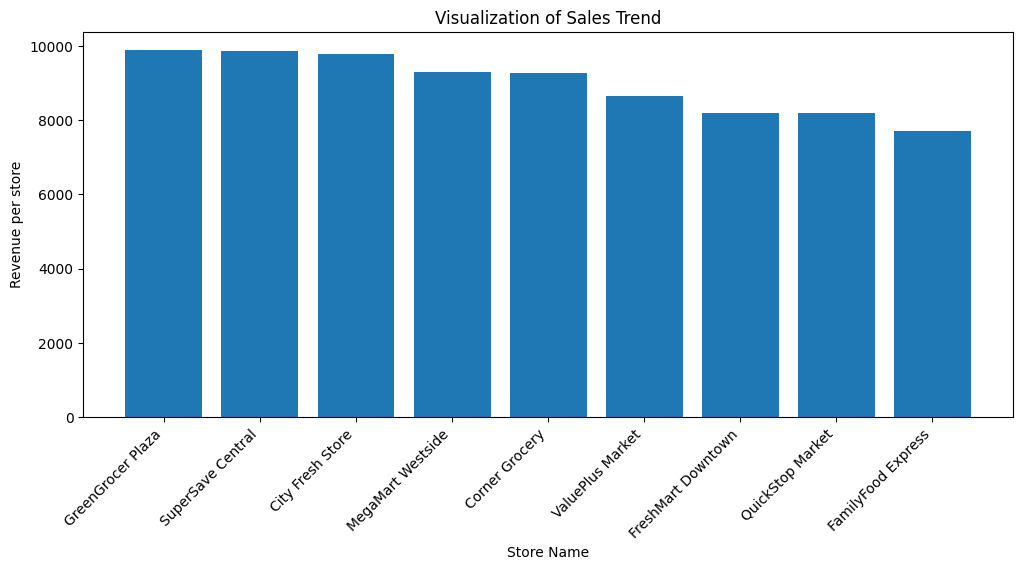

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,5))
plt.bar(revenue_per_store.index,revenue_per_store.values)
plt.xlabel('Store Name')
plt.ylabel('Revenue per store')
plt.title('Visualization of Sales Trend')
plt.xticks(rotation = 45, ha='right')
plt.show()

In [18]:
grocery_data.head(2)

,customer_id,store_name,transaction_date,aisle,product_name,quantity,unit_price,total_amount,discount_amount,final_amount,loyalty_points
0,2824,GreenGrocer Plaza,8/26/2023,Produce,Pasta,2,7.46,14.92,0.00,14.92,377
1,5506,ValuePlus Market,2/13/2024,Dairy,Cheese,1,1.85,1.85,3.41,-1.56,111


In [19]:
top = grocery_data.groupby('product_name')['quantity'].sum().sort_values(ascending = False)

In [20]:
top.head(1)

,quantity
product_name,
Chicken Breast,379


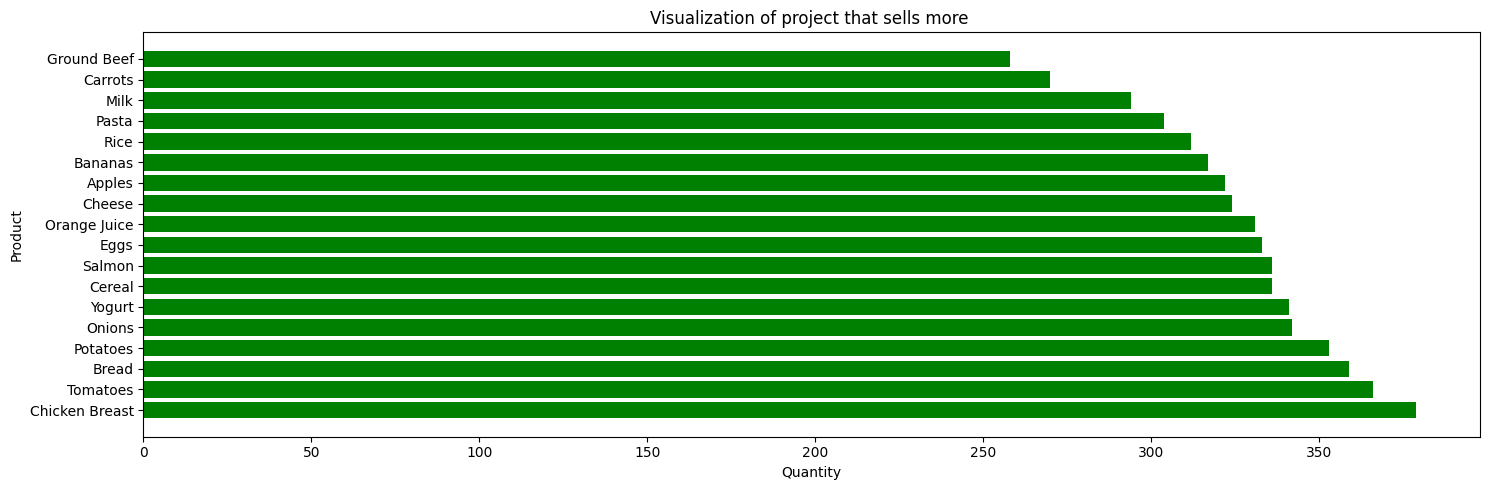

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize = (15,5))
plt.barh(top.index, top.values, color = 'green')
plt.xlabel('Quantity')
plt.ylabel('Product')
plt.title('Visualization of project that sells more ')
plt.tight_layout()
plt.show()

In [22]:
grocery_data['transaction_date'] = pd.to_datetime(grocery_data['transaction_date'])

In [23]:
print(grocery_data['transaction_date'].dtype)

datetime64[ns]


In [24]:
grocery_data['month']= grocery_data ['transaction_date'].dt.month
grocery_data['year'] = grocery_data['transaction_date'].dt.year
print(grocery_data[['transaction_date', 'month','year']].head())

  transaction_date  month  year
0       2023-08-26      8  2023
1       2024-02-13      2  2024
2       2023-11-23     11  2023
3       2025-01-13      1  2025
4       2023-10-13     10  2023


In [26]:
grocery_data.groupby(['year','month'])

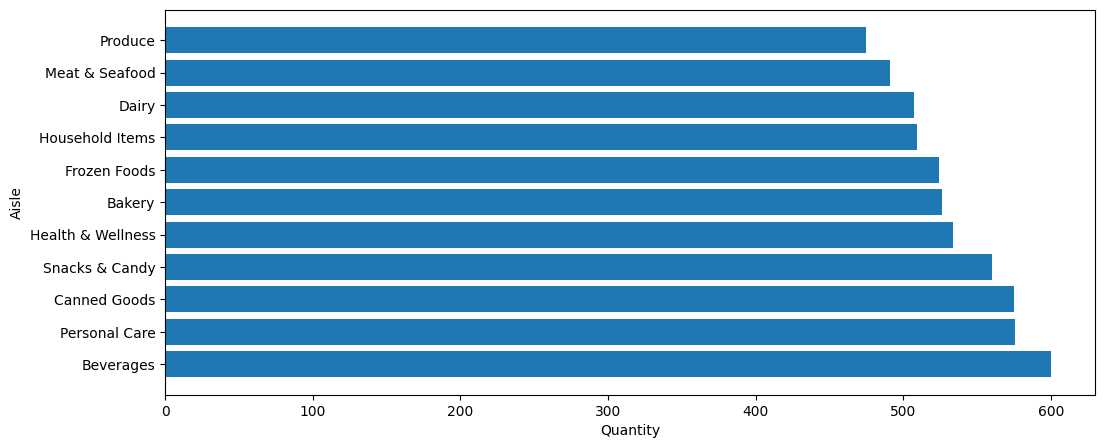

In [36]:
import matplotlib.pyplot as plt
plot = grocery_data.groupby('aisle')['quantity'].sum().sort_values(ascending = False)
plt.figure(figsize = (12,5))
plt.barh(plot.index,plot.values)
plt.xlabel('Quantity')
plt.ylabel('Aisle')
plt.show()

In [40]:
print("Average discount: $", round(grocery_data['discount_amount'].mean(), 2))

Average discount: $ 4.47


In [41]:
grocery_data.groupby('store_name')['discount_amount'].sum().sort_values(ascending = False)

,discount_amount
store_name,
City Fresh Store,1099.42
SuperSave Central,1006.35
ValuePlus Market,997.96
QuickStop Market,986.18
MegaMart Westside,978.39
Corner Grocery,968.32
GreenGrocer Plaza,966.06
FamilyFood Express,869.00
FreshMart Downtown,858.33


In [42]:
print(grocery_data[['discount_amount', 'quantity']].corr())

                 discount_amount  quantity
discount_amount         1.000000  0.335392
quantity                0.335392  1.000000
